<a href="https://colab.research.google.com/github/anayamgreen/A03-knn/blob/main/A03-kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**

1. What is the difference between regression and classification?
* Regression looks at predicting numeric outcome and Classification looks at predicting cateforical values

2. What is a confusion table? What does it help us understand about a model's performance?

* The confusion table is a matrix where it counts predictions by real values and predicted results. It helps us understand what fails in the model and what is doing really good in the model by checking False and Actual, negatives and positives.



3. What does the SSE quantify about a particular model?

* The SSE quantifies the total squared difference between the actual values and the predicted values of a model. A lower SSE means the model's predictions are closer to the actual values, indicating a better fit, while a higher SSE means the model has larger prediction errors.

4. What are overfitting and underfitting?

* Overfitting is where the model accounts for the uneccesasary values like the noise in the training data, this is also where $k$ is also lower. Underfitting the data is where the model predicts very similar data for all observations making the results very generalized, missing key patterns in the data, $k$ is also higher here.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

* The test set is used for the final evaluation of the model, while the training data is used to fit the model. Splitting the data into training and testing sets helps with model predictions because it allows us to see how well the model performs on new data that it has not already seen. Choosing $k$ by evaluating accuracy or SSE helps determine which value of $k$ gives the best results and avoids choosing a model that only performs well on the training data. The validation error helps with estimating future results on similar data and gives us a better idea of how well the model will perform on new observations.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

* With classification, a class label gives one specific prediction for what class the data belongs to. The strength of using a class label is that it is simple and gives a clear answer. However, it does not tell us how confident the model is in that prediction. A probability distribution gives the probability of the data belonging to each possible class. This is helpful because it shows how confident the model is and gives us more information about the prediction. A weakness is that it can be more difficult to understand compared to just having one class label.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

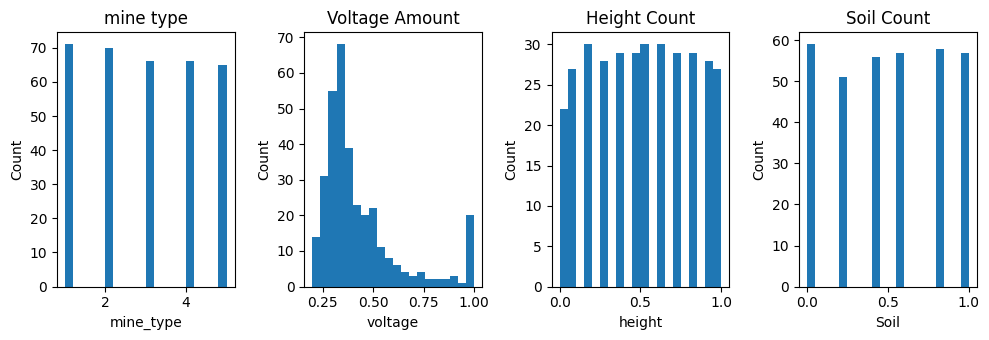

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


,mean,median,mode,Q1,Q3
voltage,0.431,0.360,1.000,0.310,0.483
height,0.509,0.545,0.182,0.273,0.727
soil,0.504,0.600,0.000,0.200,0.800


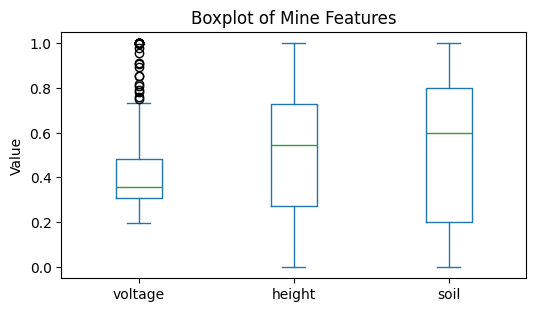

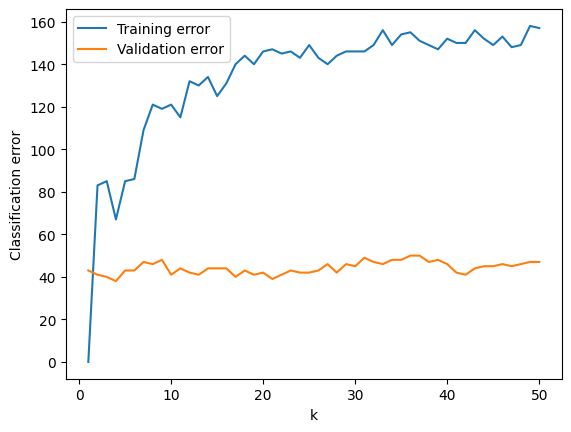

array([[10,  1,  3,  2,  5],
       [ 0, 10,  0,  5,  0],
       [ 2,  0,  3,  2,  3],
       [ 3,  2,  3,  3,  2],
       [ 0,  0,  2,  3,  4]])

In [8]:


##-------------- Question 2.1 ------------------
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#read in the csv using pd.read_csv

df = pd.read_csv('./land_mines.csv')

# print(df)

mine_type = df['mine_type']
voltage = df['voltage']
height = df['height']
soil = df['soil']

target =  df['mine_type'] # making a target variable for further use
features = df[["voltage","height","soil"]] # making a features variable

# look at the numbers of rows and columns using .shape
# print("mine_type.shape:")
# print(mine_type.shape, '\n')

# print("voltage.shape:")
# print(voltage.shape, '\n')

# print("height.shape:")
# print(height.shape, '\n')

# print("soil.shape:")
# print(soil.shape, '\n')
# Look at the first few rows of the data using .head()
mine_type.head()
# print(mine_type.unique(), '\n')
# print(mine_type.value_counts(), '\n')

voltage.head()
# print(voltage.unique(), '\n')
# print(voltage.value_counts(), '\n')

height.head()
# print(height.unique(), '\n')
# print(height.value_counts(), '\n')

soil.head()
# print(soil.unique(), '\n')
# print(soil.value_counts(), '\n')

# EDA

# Histograms

#Target
fig, axes = plt.subplots(1, 4, figsize=(10, 3.5))
mine_type.hist(bins=20, grid=False, ax=axes[0])#min_type hist
axes[0].set(title="mine type", xlabel="mine_type", ylabel="Count")# setting title and axises


#Features
voltage.hist(bins=20, grid=False, ax=axes[1])# voltage hist
axes[1].set(title="Voltage Amount", xlabel="voltage", ylabel="Count")# setting title and axises

height.hist(bins=20, grid=False, ax=axes[2])# height hist
axes[2].set(title="Height Count", xlabel="height", ylabel="Count")# setting title and axises

soil.hist(bins=20, grid=False, ax=axes[3]) # soil hist
axes[3].set(title="Soil Count", xlabel="Soil", ylabel="Count")# setting title and axises


plt.tight_layout() # making the layout more formatted
plt.show() # showing plots

# Saw that the mine_typel, height, and soil are all badly scaled. The voltage values,however, the value spread has a right skew.


#Summary statistics boxplot
print(mine_type.value_counts().sort_index())


summary = pd.DataFrame({
    "mean": features.mean(),
    "median": features.median(),
    "mode": features.mode().iloc[0],
    "Q1": features.quantile(0.25),
    "Q3": features.quantile(0.75),
})

display(summary.round(3))

features.plot.box(figsize=(6, 3.2))
plt.title("Boxplot of Mine Features")
plt.ylabel("Value")
plt.show()


# split data
from sklearn.model_selection import train_test_split # importing packages
from sklearn.preprocessing import MinMaxScaler


# spliting raw data (couldve also used features and target variables, but might use that for later analysis)
eval_X_raw = df[["voltage","height","soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.20, random_state=65
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw) # computing the minima and maxima training and scales the features
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw) # transform uses these values to scale and validate the features


#builing a K-NN classifier
from sklearn.neighbors import KNeighborsClassifier # load package, use classifier for categorical variable
eval_ks = np.arange(1, 51)
eval_valid_error = []
eval_train_error = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_error.append(np.sum(
        eval_y_valid.to_numpy() != eval_valid_hat
    ))
    eval_train_error.append(np.sum(
        eval_y_train.to_numpy() != eval_train_hat
    ))
eval_k_star = int(eval_ks[np.argmin(eval_valid_error)])


# comparing K
plt.plot(eval_ks, eval_train_error, label="Training error")
plt.plot(eval_ks, eval_valid_error, label="Validation error")

plt.xlabel("k")
plt.ylabel("Classification error")
plt.legend()
plt.show()
# I compared the values of K from 1-50 then calculated the training and validation classification errors for each value
# At very small K, predictions closely follow the training data, so the training classification error is low
# The selected value I used that minimized the validation error was around 4.


# Fit classifier using optimal k
from sklearn.neighbors import KNeighborsClassifier # load in packages
classification_model = KNeighborsClassifier(
    n_neighbors=eval_k_star).fit(eval_X_train_scaled, eval_y_train)

# Predict validation data
eval_valid_hat = classification_model.predict(eval_X_valid_scaled)


# confusion matrix off the optmized K value
from sklearn.metrics import confusion_matrix
confusion_matrix(eval_y_valid, eval_valid_hat)

# Each row of the confusion table is mine_type and the columns are the predicted minetyoes
# This model correctly classified about half of the observations in the validation set, giving the overall accuracy of 44.1%.
#It performs  better on type 2 with about 66% correct. The confusion matrix shows that the model frequently confuses different mine types.


---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

In [ ]:
# Your Phase 1 solution to the problem goes here.


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]